<img src="imgs\banner_fcd.jpg" alt="bannersp" width="1100"  height="150">

## <span style="color:#2F749F;"><strong>📦 Sesión práctica 4: Detección de datos atípicos</strong></span>
---
<p align="right">
  <a href="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_4_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>


## <span style="color:black;"><strong>Datos del estudiante</strong></span>

Lukas Piedrahita --- 1040872196

Carlos Rodríguez --- 1128266552

# <span style="color:#2F749F;"><strong>Ejercicio 1: Intervalo IQR</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

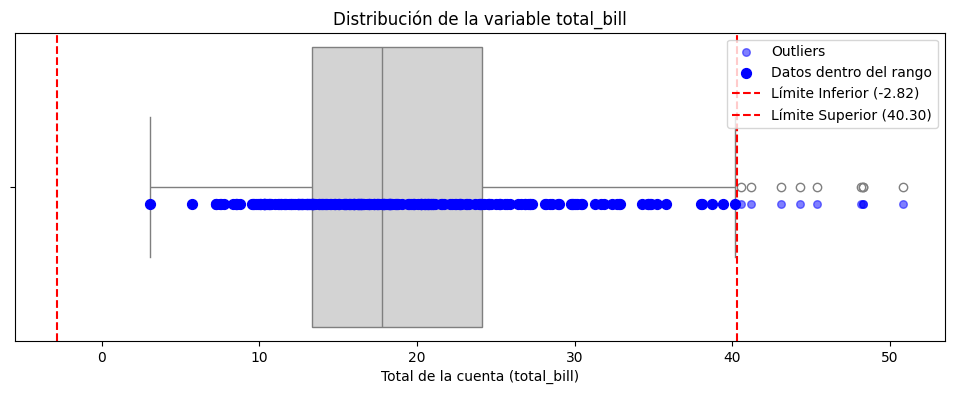

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

tips = sns.load_dataset("tips")
total_bill = tips["total_bill"].values
Q1, Q3 = np.percentile(total_bill, [25, 75])
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR
data_a = total_bill[(total_bill < lim_inf) | (total_bill > lim_sup)]
data_b = total_bill[(total_bill >= lim_inf) & (total_bill <= lim_sup)]

plt.figure(figsize=(12,4))
sns.boxplot(x=total_bill, color="lightgray")
plt.scatter(data_a, [0.05]*len(data_a), color="blue", s=30, alpha=0.5, label="Outliers")
plt.scatter(data_b, [0.05]*len(data_b), color="blue", s=50, zorder=5, label="Datos dentro del rango")
plt.axvline(lim_inf, color='red', linestyle='--', label=f'Límite Inferior ({lim_inf:.2f})')
plt.axvline(lim_sup, color='red', linestyle='--', label=f'Límite Superior ({lim_sup:.2f})')
plt.title("Distribución de la variable total_bill")
plt.xlabel("Total de la cuenta (total_bill)")
plt.legend()
plt.show()


**Análisis:** En la gráfica se pueden observar que hay datos que se clasifican como outliers que quedan fuera de los limites superior e inferior graficados y calculados a través del método IQR. Estos datos outliers son los que se encuentran más alejados de zona central donde se encuentran distribuidos los datos.

# <span style="color:#2F749F;"><strong>Ejercicio 2: Graficos de dispersión</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

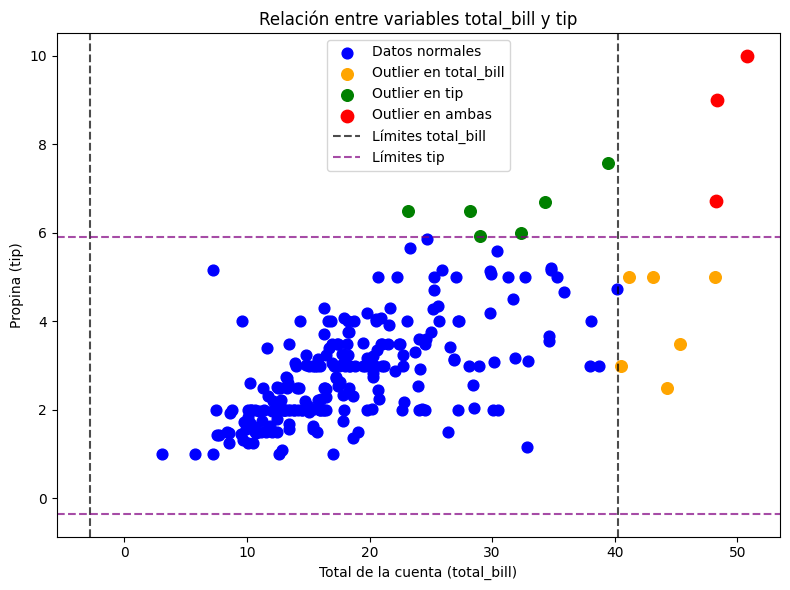

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

tips = sns.load_dataset("tips")

x = tips["total_bill"].values
y = tips["tip"].values

Q1_x, Q3_x = np.percentile(x, [25, 75])
IQR_x = Q3_x - Q1_x
lim_inf_x = Q1_x - 1.5 * IQR_x
lim_sup_x = Q3_x + 1.5 * IQR_x
Q1_y, Q3_y = np.percentile(y, [25, 75])
IQR_y = Q3_y - Q1_y
lim_inf_y = Q1_y - 1.5 * IQR_y
lim_sup_y = Q3_y + 1.5 * IQR_y

normal = (x >= lim_inf_x) & (x <= lim_sup_x) & (y >= lim_inf_y) & (y <= lim_sup_y)
out_x = ((x < lim_inf_x) | (x > lim_sup_x)) & (y >= lim_inf_y) & (y <= lim_sup_y)
out_y = ((y < lim_inf_y) | (y > lim_sup_y)) & (x >= lim_inf_x) & (x <= lim_sup_x)
out_both = ((x < lim_inf_x) | (x > lim_sup_x)) & ((y < lim_inf_y) | (y > lim_sup_y))

plt.figure(figsize=(8,6))
plt.scatter(x[normal], y[normal], color='blue', s=60, label='Datos normales')
plt.scatter(x[out_x], y[out_x], color='orange', s=70, label='Outlier en total_bill')
plt.scatter(x[out_y], y[out_y], color='green', s=70, label='Outlier en tip')
plt.scatter(x[out_both], y[out_both], color='red', s=80, label='Outlier en ambas')
plt.axvline(lim_inf_x, color='black', linestyle='--', alpha=0.7, label='Límites total_bill')
plt.axvline(lim_sup_x, color='black', linestyle='--', alpha=0.7)
plt.axhline(lim_inf_y, color='purple', linestyle='--', alpha=0.7, label='Límites tip')
plt.axhline(lim_sup_y, color='purple', linestyle='--', alpha=0.7)
plt.title("Relación entre variables total_bill y tip")
plt.xlabel("Total de la cuenta (total_bill)")
plt.ylabel("Propina (tip)")
plt.legend()
plt.tight_layout()
plt.show()

**Análisis:** En la gráfica se observa la distribución de datos según dos variables, y a cada una de estas se le hizo un análisis IQR para identificar outliers agregando sus respectivos limites a la gráfica, diferenciando entre outliers que se consideran como outliers solo para cada una de las variables de forma independiente según sus límites establecidos, y los que se consideran outliers en ambas variables a la vez.

# <span style="color:#2F749F;"><strong>Ejercicio 3: Histogramas y funciones de densidad</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

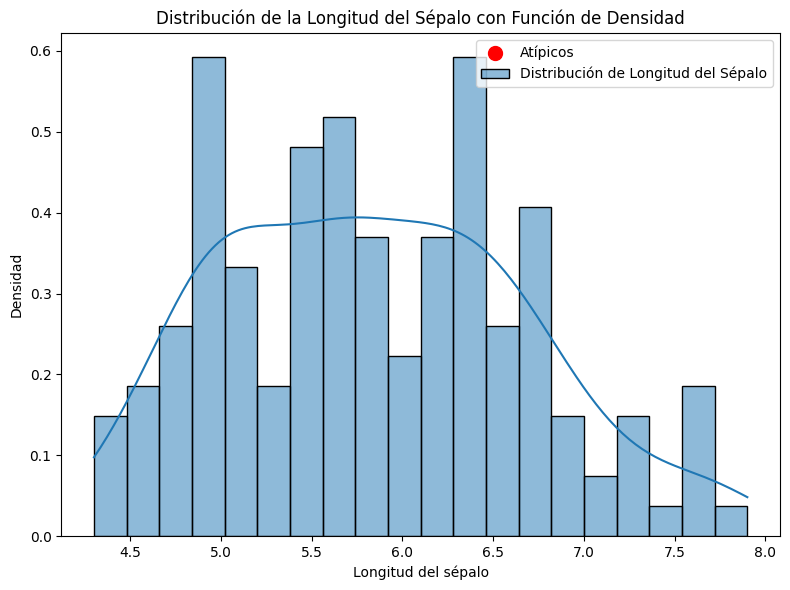

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

iris = sns.load_dataset("iris")
x = iris["sepal_length"].values

Q1, Q3 = np.percentile(x, [25, 75])
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR
outliers = x[(x < lim_inf) | (x > lim_sup)]

plt.figure(figsize=(8,6))
sns.histplot(x=x, bins=20, kde=True, label="Distribución de Longitud del Sépalo", stat="density")
plt.scatter(outliers, np.zeros_like(outliers), color='red', label="Atípicos", s=100, zorder=5)
plt.xlabel("Longitud del sépalo")
plt.ylabel("Densidad")
plt.title("Distribución de la Longitud del Sépalo con Función de Densidad")
plt.legend()
plt.tight_layout()
plt.show()

**Análisis:** En la gráfica se observa la distribución en función de densidad de los datos analizados (longitud del sépalo). A primera vista no se identificaron outliers obvios en el histograma, por lo que se le añadio una función que usa el cálculo IQR para gráficar puntos outliers identificados con este método para validar que en efecto no se encontraron outliers en los datos.

# <span style="color:#2F749F;"><strong>Ejercicio 4: Z-Score</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

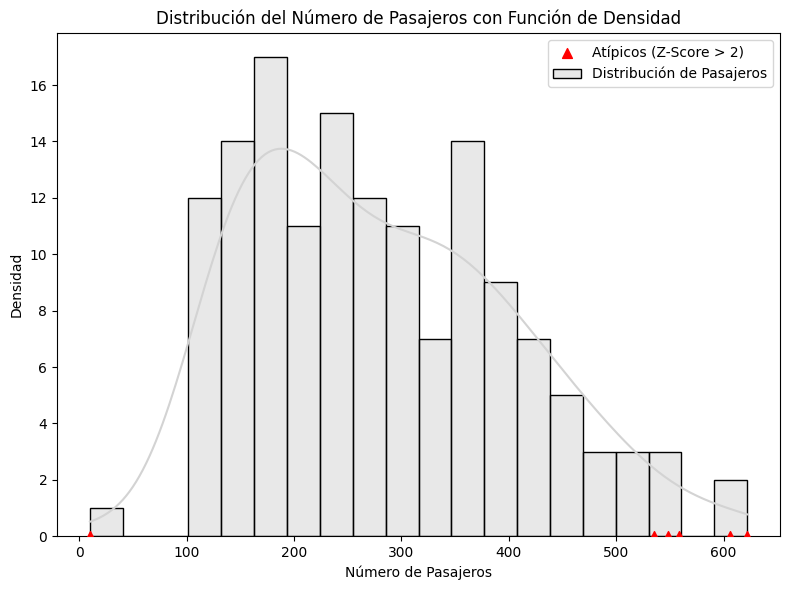

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore

flights = sns.load_dataset("flights")
x = flights["passengers"].values

x = np.append(x, [10, 500])

z_scores = zscore(x)
data_b = np.abs(z_scores) > 2

plt.figure(figsize=(8,6))
sns.histplot(x=x, bins=20, kde=True, color="lightgray", label="Distribución de Pasajeros")
plt.scatter(x[data_b], np.zeros_like(x[data_b]), color="red", s=50, marker="^", label="Atípicos (Z-Score > 2)", zorder=5)
plt.xlabel("Número de Pasajeros")
plt.ylabel("Densidad")
plt.title("Distribución del Número de Pasajeros con Función de Densidad")
plt.legend()
plt.tight_layout()
plt.show()


**Análisis:** En la gráfica se observa la distribución de los datos (número de pasajeros) en función de la densidad. En la gráfica se observan barras del histograma separadas del resto, por lo que se pueden considerar como outliers, las cuáles al gráficar los puntos obtenidos como outliers a través del método Z-Score, se puede confirmar que se clasifican de esta manera. Tambipen se encontraron outliers en una barra que no estaba separada de resto del histograma, pero que sus puntajes superaban los establecidos por el Z-Score.